# The Chart Detective

**Stock:** BAJFINANCE.NS  
**Backtest Period:** 25 August 2025 – 24 August 2026


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os


## 1. Downloading Data

Downlaoding historical data of 2 years to allow EMA to stabilise

In [27]:
ticker = "BAJFINANCE.NS"

start_date = "2025-08-25"
end_date = "2026-08-24"

print("Instrument:", ticker)
print("Backtest period:", start_date, "to", end_date)

Instrument: BAJFINANCE.NS
Backtest period: 2025-08-25 to 2026-08-24


## 2. Calculating the EMA Indicators


In [ ]:
full_data = yf.download(
    ticker,
    period="2y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

if isinstance(full_data.columns, pd.MultiIndex):
    full_data.columns = full_data.columns.get_level_values(0)

full_data = full_data.dropna()

print("Historical data start:", full_data.index.min())
print("Historical data end:", full_data.index.max())
print("Number of trading days:", len(full_data))

Historical data start: 2024-08-28 00:00:00
Historical data end: 2026-08-27 00:00:00
Number of trading days: 500


In [29]:
full_data["EMA20"] = full_data["Close"].ewm(
    span=20,
    adjust=False
).mean()

full_data["EMA50"] = full_data["Close"].ewm(
    span=50,
    adjust=False
).mean()
data = full_data.loc[start_date:end_date].copy()

print("Backtest start:", data.index.min())
print("Backtest end:", data.index.max())
print("Trading days:", len(data))

Backtest start: 2025-08-25 00:00:00
Backtest end: 2026-08-24 00:00:00
Trading days: 250


## 3. Detecting Buy and Sell Signals

A bullish crossover is generated when the 20-day EMA moves above the 50-day EMA.

A bearish crossover is generated when the 20-day EMA moves below the 50-day EMA.

In [30]:
# Store previous day's EMA values
data["Prev_EMA20"] = data["EMA20"].shift(1)
data["Prev_EMA50"] = data["EMA50"].shift(1)

# BUY signal:
# 20 EMA moves from below/equal to above the 50 EMA
data["Bullish_Crossover"] = (
    (data["EMA20"] > data["EMA50"]) &
    (data["Prev_EMA20"] <= data["Prev_EMA50"])
)

# SELL signal:
# 20 EMA moves from above/equal to below the 50 EMA
data["Bearish_Crossover"] = (
    (data["EMA20"] < data["EMA50"]) &
    (data["Prev_EMA20"] >= data["Prev_EMA50"])
)

In [31]:
crossovers = data[
    data["Bullish_Crossover"] |
    data["Bearish_Crossover"]
]

crossovers[
    [
        "Close",
        "EMA20",
        "EMA50",
        "Bullish_Crossover",
        "Bearish_Crossover"
    ]
]

Price,Close,EMA20,EMA50,Bullish_Crossover,Bearish_Crossover
Date,,,,,
2025-09-09,948.400024,906.774210,904.812879,True,False
2025-12-19,1008.299988,1014.792881,1015.069563,False,True
2026-02-18,1023.799988,980.907272,979.762382,True,False
2026-03-09,938.049988,981.110658,982.809764,False,True
2026-05-05,958.599976,921.601830,921.287992,True,False
2026-05-21,907.650024,922.696634,923.166006,False,True
2026-05-25,941.900024,923.995885,923.651397,True,False
2026-06-01,889.049988,920.769229,922.465280,False,True
2026-06-18,958.849976,918.149936,917.472694,True,False


## 4. Trade Generation

A buy trade was generated when the 20-day EMA crossed above the 50-day EMA. A sell/exit signal was generated when the 20-day EMA crossed below the 50-day EMA. Each completed trade's return was calculated using the entry and exit prices.              

In [32]:
trades = []

in_trade = False
entry_date = None
entry_price = None

for date, row in data.iterrows():

    # Enter when a bullish crossover occurs
    if row["Bullish_Crossover"] and not in_trade:

        entry_date = date
        entry_price = row["Close"]
        in_trade = True

    # Exit when a bearish crossover occurs
    elif row["Bearish_Crossover"] and in_trade:

        exit_date = date
        exit_price = row["Close"]

        pnl_percent = (
            (exit_price - entry_price)
            / entry_price
        ) * 100

        trades.append({
            "Entry Date": entry_date,
            "Entry Price": entry_price,
            "Exit Date": exit_date,
            "Exit Price": exit_price,
            "P&L %": pnl_percent
        })

        in_trade = False


trade_log = pd.DataFrame(trades)

trade_log.insert(
    0,
    "Trade Number",
    range(1, len(trade_log) + 1)
)

trade_log

,Trade Number,Entry Date,Entry Price,Exit Date,Exit Price,P&L %
0,1,2025-09-09,948.400024,2025-12-19,1008.299988,6.315896
1,2,2026-02-18,1023.799988,2026-03-09,938.049988,-8.375659
2,3,2026-05-05,958.599976,2026-05-21,907.650024,-5.315038
3,4,2026-05-25,941.900024,2026-06-01,889.049988,-5.611003


In [33]:
total_trades = len(trade_log)

winners = len(
    trade_log[trade_log["P&L %"] > 0]
)

win_rate = (
    winners / total_trades * 100
    if total_trades > 0
    else 0
)

largest_winner = trade_log["P&L %"].max()
largest_loser = trade_log["P&L %"].min()


summary = pd.DataFrame({
    "Metric": [
        "Instrument",
        "Backtest Start",
        "Backtest End",
        "Total Trades",
        "Winning Trades",
        "Losing Trades",
        "Win Rate (%)",
        "Largest Winner (%)",
        "Largest Loser (%)"
    ],

    "Value": [
        ticker,
        start_date,
        end_date,
        total_trades,
        winners,
        total_trades - winners,
        round(win_rate, 2),
        round(largest_winner, 2),
        round(largest_loser, 2)
    ]
})

summary


,Metric,Value
0,Instrument,BAJFINANCE.NS
1,Backtest Start,2025-08-25
2,Backtest End,2026-08-24
3,Total Trades,4
4,Winning Trades,1
5,Losing Trades,3
6,Win Rate (%),25.0
7,Largest Winner (%),6.32
8,Largest Loser (%),-8.38


In [34]:
import os

os.makedirs("screenshots", exist_ok=True)

print("Screenshots folder created!")

Screenshots folder created!


## 6. Visual Analysis

The following charts show the overall performance of the strategy over the full backtest period, as well as the best and worst completed trades.

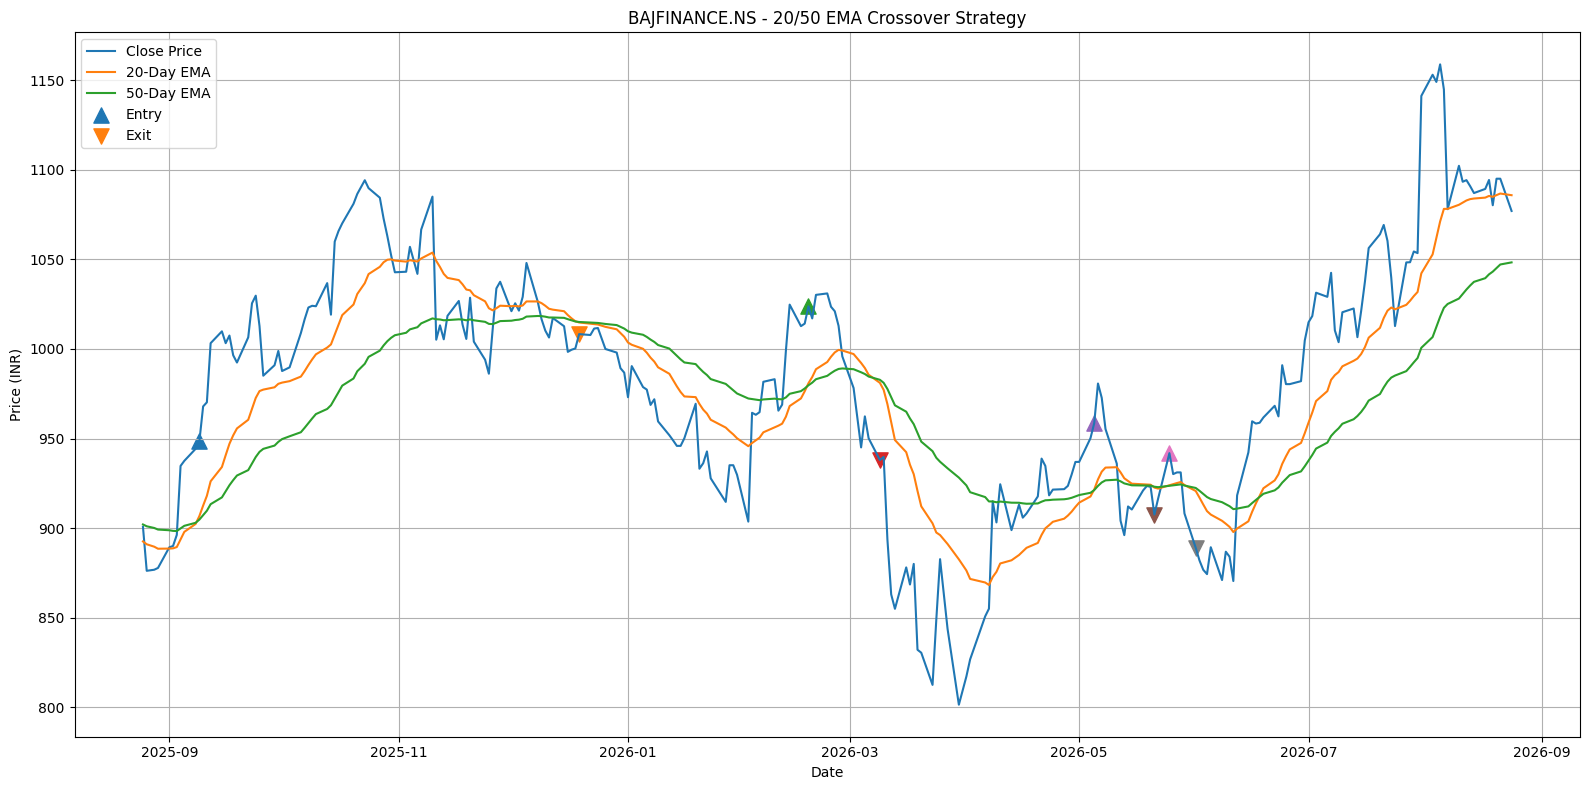

In [35]:
plt.figure(figsize=(16, 8))

plt.plot(
    data.index,
    data["Close"],
    label="Close Price"
)

plt.plot(
    data.index,
    data["EMA20"],
    label="20-Day EMA"
)

plt.plot(
    data.index,
    data["EMA50"],
    label="50-Day EMA"
)


# Mark completed trade entries and exits
for _, trade in trade_log.iterrows():

    plt.scatter(
        trade["Entry Date"],
        trade["Entry Price"],
        marker="^",
        s=120,
        label="Entry" if trade["Trade Number"] == 1 else ""
    )

    plt.scatter(
        trade["Exit Date"],
        trade["Exit Price"],
        marker="v",
        s=120,
        label="Exit" if trade["Trade Number"] == 1 else ""
    )


plt.title(
    "BAJFINANCE.NS - 20/50 EMA Crossover Strategy"
)

plt.xlabel("Date")
plt.ylabel("Price (INR)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "screenshots/full_12_month_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

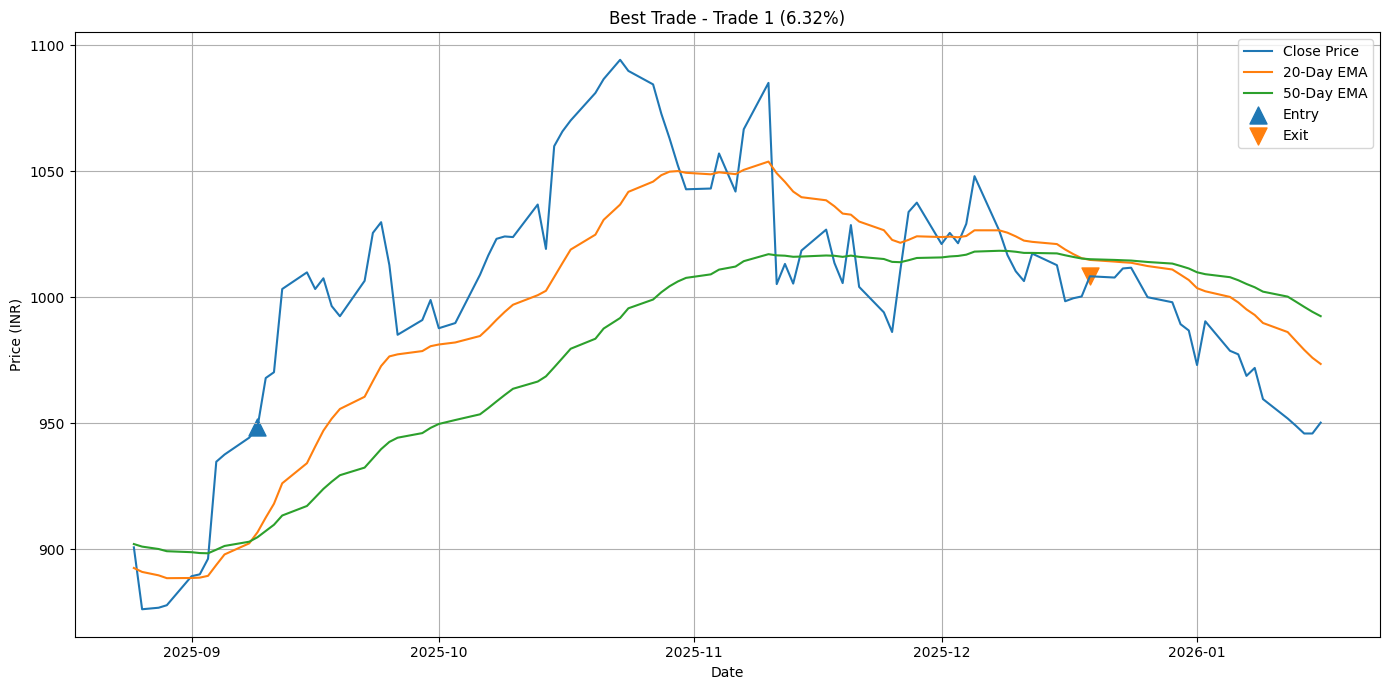

In [36]:
best_trade = trade_log.loc[
    trade_log["P&L %"].idxmax()
]

start = (
    best_trade["Entry Date"]
    - pd.Timedelta(days=30)
)

end = (
    best_trade["Exit Date"]
    + pd.Timedelta(days=30)
)

best_data = data.loc[start:end]


plt.figure(figsize=(14, 7))

plt.plot(
    best_data.index,
    best_data["Close"],
    label="Close Price"
)

plt.plot(
    best_data.index,
    best_data["EMA20"],
    label="20-Day EMA"
)

plt.plot(
    best_data.index,
    best_data["EMA50"],
    label="50-Day EMA"
)


plt.scatter(
    best_trade["Entry Date"],
    best_trade["Entry Price"],
    marker="^",
    s=150,
    label="Entry"
)

plt.scatter(
    best_trade["Exit Date"],
    best_trade["Exit Price"],
    marker="v",
    s=150,
    label="Exit"
)


plt.title(
    f"Best Trade - Trade {best_trade['Trade Number']} "
    f"({best_trade['P&L %']:.2f}%)"
)

plt.xlabel("Date")
plt.ylabel("Price (INR)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "screenshots/best_trade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

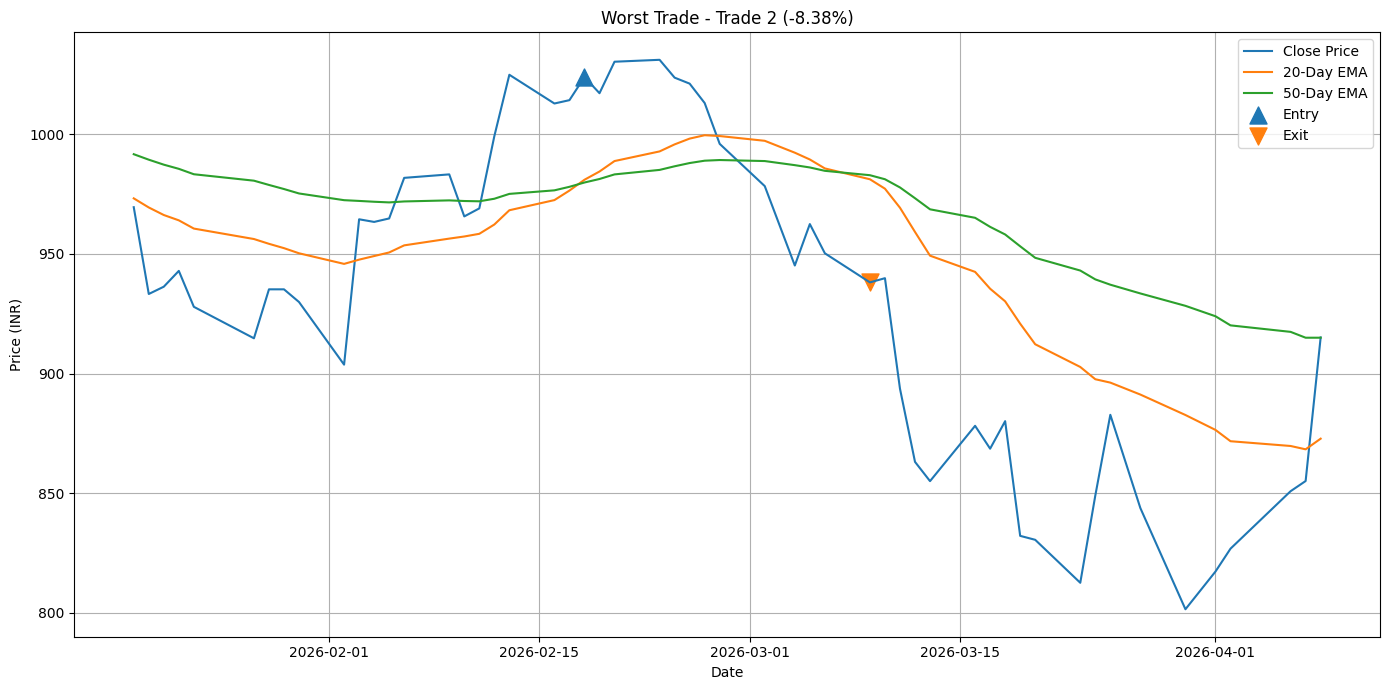

In [37]:
worst_trade = trade_log.loc[
    trade_log["P&L %"].idxmin()
]

start = (
    worst_trade["Entry Date"]
    - pd.Timedelta(days=30)
)

end = (
    worst_trade["Exit Date"]
    + pd.Timedelta(days=30)
)

worst_data = data.loc[start:end]


plt.figure(figsize=(14, 7))

plt.plot(
    worst_data.index,
    worst_data["Close"],
    label="Close Price"
)

plt.plot(
    worst_data.index,
    worst_data["EMA20"],
    label="20-Day EMA"
)

plt.plot(
    worst_data.index,
    worst_data["EMA50"],
    label="50-Day EMA"
)


plt.scatter(
    worst_trade["Entry Date"],
    worst_trade["Entry Price"],
    marker="^",
    s=150,
    label="Entry"
)

plt.scatter(
    worst_trade["Exit Date"],
    worst_trade["Exit Price"],
    marker="v",
    s=150,
    label="Exit"
)


plt.title(
    f"Worst Trade - Trade {worst_trade['Trade Number']} "
    f"({worst_trade['P&L %']:.2f}%)"
)

plt.xlabel("Date")
plt.ylabel("Price (INR)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "screenshots/worst_trade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
export_trade_log = trade_log.copy()

export_trade_log["Entry Price"] = (
    export_trade_log["Entry Price"].round(2)
)

export_trade_log["Exit Price"] = (
    export_trade_log["Exit Price"].round(2)
)

export_trade_log["P&L %"] = (
    export_trade_log["P&L %"].round(2)
)


export_trade_log.to_csv(
    "trade_log.csv",
    index=False
)

print("trade_log.csv created successfully!")

trade_log.csv created successfully!


In [39]:
compounded_return = (
    (1 + trade_log["P&L %"] / 100).prod() - 1
) * 100

print(f"Compounded Strategy Return: {compounded_return:.2f}%")

Compounded Strategy Return: -12.94%
